# Python Data Science and Visualization Basics Tutorial

Welcome to the MBAI 5400G *Python Data Science and Visualization Basics* tutorial. We're going to look at some very basic concepts related to data visualization in Python using the most common visualization libraries, including Matplotlib, Pandas, Seaborn, and more.

To follow along, either download the .ipynb and data folder and run them locally, or copy both of them and move the copies to your own Google Drive in order to run using Colab.

## Today's Topics

- Python Data Science Basics
- Python Visualization Libraries
- Additional Resources

## Introduction

When you first start doing data science and visualization in Python, it can very overwhelming. There are all sorts of different libraries for data processing, visualization, machine learning, and so on. Some of them are active and updated, but many are not! This landscape diagram highlights the wide variety of different Python libraries and frameworks that are regularly used in data science research and practice. You shouldn't expect to learn all of them, but you may have to work with some of the more prominent ones along your path in this program.

<img src='https://drive.google.com/uc?id=1M86qjwVhHiXZLS1PKJYD2bC9EHaXDy6E'>

When it comes to visualization in Python, the landscape is even messier. While Matplotlib is arguably the foundation of Python visualization, there are a significant number of complex tools that can be difficult to learn. Our goal today is to take a wide view that examines only the basics of a select number of Python libraries.

<img src='https://drive.google.com/uc?id=1XbczKhazwGDxQomhhtQ9P21JznjK4C31'>

## Today's Case Study: Canada's Consumer Price Index (CPI)

To take this wide view, we're going to start by collecting some topical data. Stats Canada produces a Consumer Price Index (CPI) dataset that tracks changes in prices as experienced by Canadian consumers by comparing, through time, the cost of a fixed basket of goods and services. It reflects a weighted average of prices representative of aggregate consumer spending. The video below, from Stats Canada, provides a solid overview of how the CPI works.

In [ ]:
%%html
<p><iframe width="560" height="315" src="https://www.youtube.com/embed/qfKmJe3CK6E?si=QNDzIdTnMT3-uUey" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe></p>

Let's start by getting the CPI data. There are a few steps we will need to take...

- First, you should go to Stats Canada's CPI portal and read about the data https://www.statcan.gc.ca/eng/subjects-start/prices_and_price_indexes/consumer_price_indexes
- You can also try out their visualization tool https://www150.statcan.gc.ca/n1/pub/71-607-x/71-607-x2018016-eng.htm
- Next, access the specific data table that we're going to use today https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1810000501
- Adjust and apply the following date range: 2002-2024 (make sure to press the "Apply" button!)
- Download .csv (as displayed)
- For your convenience, the .csv has already been shared in the course Shared Drive


## pandas for Data Science

pandas.svg

Now that we've got some data, let's take a look at the most important tool in your Python data science Swiss Army knife: pandas! pandas is a fast, powerful, and flexible Python software library for data manipulation and analysis. It offers data structures and operations for manipulating numerical tables and time series. Think of it like Excel on steroids. You can use it to get information about your data, to clean up your data, and to inspect your data in a table view. You will use pandas extensively in this program.

You can read more about it here: https://pandas.pydata.org/

In [ ]:
# import the pandas library
import pandas as pd

Note: before you can load the .csv from Stats Can into Pandas, you'll need to remove a bunch of the metadata that turns up in the imported file. If you open it using Excel/Calc/Sheets, you should delete rows 1-9, 11, and 27-45. You can also open the .csv in a text editor and remove these lines by hand. (A cleaned up version is provided in the /data/ folder, and can be loaded with the following code.)

In [ ]:
# This is unnecessary if you plan to run the notebook from JupyterLab (locally, or from the OTU hub at https://hub.science.ontariotechu.ca/)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load the dataset
# if running locally, you should have the notebook and a data folder in the same main directory
# then your path will look like df = pd.read_csv('data/1810000501-eng.csv')
df = pd.read_csv("/content/drive/Shareddrives/MBAI 5400G - Visualization and Storytelling (Winter 2026)/In-Class Activities/Python Visualization/data/1810000501-eng.csv")

In [ ]:
# the info method prints information about a DataFrame
# it includes the data types, columns, non-null values, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Products and product groups  15 non-null     object 
 1   2002                         15 non-null     int64  
 2   2003                         15 non-null     float64
 3   2004                         15 non-null     float64
 4   2005                         15 non-null     float64
 5   2006                         15 non-null     float64
 6   2007                         15 non-null     float64
 7   2008                         15 non-null     float64
 8   2009                         15 non-null     float64
 9   2010                         15 non-null     float64
 10  2011                         15 non-null     float64
 11  2012                         15 non-null     float64
 12  2013                         15 non-null     float64
 13  2014                  

In [ ]:
# the head method returns the first n rows for the object based on position
# it is useful for quickly examining your DataFrame
# it will return the first five rows if no number is specified
df.head()

,Products and product groups,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,All-items,100,102.8,104.7,107.0,109.1,111.5,114.1,114.4,116.5,...,126.6,128.4,130.4,133.4,136.0,137.0,141.6,151.2,157.1,160.9
1,Food,100,101.7,103.8,106.4,108.9,111.8,115.7,121.4,123.1,...,140.5,142.6,142.7,145.3,150.2,153.7,157.5,171.5,184.3,189.3
2,Shelter,100,103.2,105.8,109.2,113.1,116.9,122.0,121.6,123.3,...,133.7,135.8,138.1,140.9,144.5,147.0,152.7,163.3,172.5,182.3
3,"Household operations, furnishings and equipment",100,100.7,101.2,101.7,102.2,103.2,104.6,107.3,108.8,...,119.7,121.7,121.9,123.2,123.6,123.8,125.2,130.9,132.0,130.7
4,Clothing and footwear,100,98.2,98.0,97.6,95.8,95.7,93.8,93.4,91.6,...,94.6,94.4,93.7,94.5,96.1,94.4,94.1,95.4,96.4,93.3


pandas also makes it easy to create subsets of data. Think of this as similar to creating a new sheet in Excel.

In [ ]:
# create a DataFrame with just the first three rows
df_subset = df[:3]
df_subset.head()

,Products and product groups,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,All-items,100,102.8,104.7,107.0,109.1,111.5,114.1,114.4,116.5,...,126.6,128.4,130.4,133.4,136.0,137.0,141.6,151.2,157.1,160.9
1,Food,100,101.7,103.8,106.4,108.9,111.8,115.7,121.4,123.1,...,140.5,142.6,142.7,145.3,150.2,153.7,157.5,171.5,184.3,189.3
2,Shelter,100,103.2,105.8,109.2,113.1,116.9,122.0,121.6,123.3,...,133.7,135.8,138.1,140.9,144.5,147.0,152.7,163.3,172.5,182.3


Sometimes, you will want to "flip" your dataset from a wide view to a long view. The transpose method will reflect your dataframe over its main diagonal by writing rows as columns and vice-versa. The property T is an accessor to the method transpose().

In [ ]:
df_trans = df.set_index('Products and product groups').T
df_trans.head(7)

Products and product groups,All-items,Food,Shelter,"Household operations, furnishings and equipment",Clothing and footwear,Transportation,Gasoline,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis",All-items excluding food and energy,All-items excluding energy,Energy,Goods,Services
2002,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2003,102.8,101.7,103.2,100.7,98.2,105.2,106.4,101.4,100.8,110.1,102.5,102.4,107.9,101.9,103.6
2004,104.7,103.8,105.8,101.2,98.0,107.7,117.6,102.8,101.1,116.0,103.9,103.8,115.2,103.4,105.9
2005,107.0,106.4,109.2,101.7,97.6,112.0,132.6,104.6,100.8,119.1,105.3,105.4,126.3,105.8,108.2
2006,109.1,108.9,113.1,102.2,95.8,115.2,139.8,105.9,100.6,121.7,106.9,107.2,132.8,107.1,111.1
2007,111.5,111.8,116.9,103.2,95.7,117.1,146.1,107.3,101.8,125.5,109.0,109.5,135.9,108.0,114.8
2008,114.1,115.7,122.0,104.6,93.8,119.5,164.7,108.8,102.2,127.5,110.3,111.3,149.3,109.4,118.7


Earlier, we loaded the data from a downloaded .csv file. We can also use the Stats Can Python API to get the data. There is a convenient library that you can read more about (and install from) here: https://stats-can.readthedocs.io/en/latest/

In [ ]:
#import stats_can
#from stats_can import StatsCan

# declare a data folder
#sc = StatsCan(data_folder="./Data")

# collect the table you want
#df = sc.table_to_df("18-10-0005-01")
#df.head()

# Convert the date to datetime64
#df['REF_DATE'] = pd.to_datetime(df['REF_DATE'], format='%Y-%m-%d')

# Filter data between 2002 and 2024
#filtered_df = df.loc[(df['REF_DATE'] >= '2002-01-01')
#                     & (df['REF_DATE'] < '2024-01-01')]

#filtered_df.head()

In [ ]:
# if you just want data for all items, food, and shelter, use this code
#df = sc.vectors_to_df(["v41693271", "v41693272", "v41693348"], periods = 23)
#df.columns = ['All-items', 'Food', 'Shelter']
#df.index.names = ['Year']
#df.head()

There's lots to learn when it comes to pandas. One thing you should be aware of, though, is how tricky it can be to remember the state of your notebook when you only use "df" to name DataFrames. Try to come up with names that are a little more descriptive! There is an ongoing debate in the Python data science community about this specific topic!

<img src='https://drive.google.com/uc?id=1ASUWjXYiS_lBwfMNU-Swq_ZYUHc17Bnn'>


## pandas for Visualization

One nice thing about relying on pandas for data processing is that it also has built-in visualization capacity with Matplotlib - the foundation of most Python visualization - as its default back-end.

In [ ]:
# we'll start by importing matplotlib using pyplot (more on this in a minute)
import matplotlib.pyplot as plt

# and let's reload our data with a cleaned up and transposed .csv
df = pd.read_csv("/content/drive/Shareddrives/MBAI 5400G - Visualization and Storytelling (Winter 2026)/In-Class Activities/Python Visualization/data/cpi.csv")

In [ ]:
df.head()

,Years,All-items,Food,Shelter,"Household operations, furnishings and equipment",Clothing and footwear,Transportation,Gasoline,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis",All-items excluding food and energy,All-items excluding energy,Energy,Goods,Services
0,2002,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,2003,102.8,101.7,103.2,100.7,98.2,105.2,106.4,101.4,100.8,110.1,102.5,102.4,107.9,101.9,103.6
2,2004,104.7,103.8,105.8,101.2,98.0,107.7,117.6,102.8,101.1,116.0,103.9,103.8,115.2,103.4,105.9
3,2005,107.0,106.4,109.2,101.7,97.6,112.0,132.6,104.6,100.8,119.1,105.3,105.4,126.3,105.8,108.2
4,2006,109.1,108.9,113.1,102.2,95.8,115.2,139.8,105.9,100.6,121.7,106.9,107.2,132.8,107.1,111.1


We're going to use a visualization method for time series data that you're all likely familiar with - a line chart (or line plot, line graph, time series visualization, etc.) Here's a great overview that covers how line charts work: https://www.storytellingwithdata.com/blog/2020/3/24/what-is-a-line-graph

Because pandas uses Matplotlib as its back-end, you don't need to do much to spit out a simple line chart.

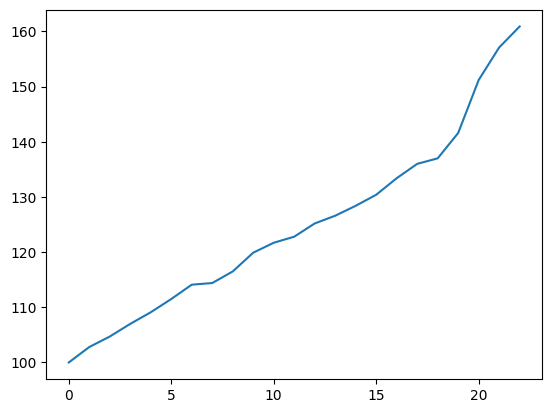

In [ ]:
# this is all the code you need
df['All-items'].plot();

The blue line visualizes the "All-items" basket of the CPI. If we want to add additional categories (e.g. food and shelter), we can do so by adding a few more lines. Note that we're using plt.show() in our code, but most notebook software will let you get away with a simple semi-colon instead.

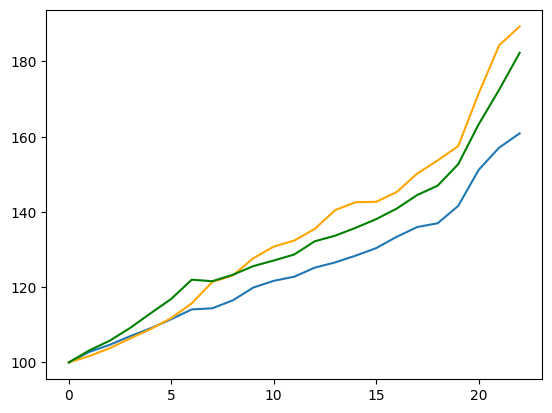

In [ ]:
df["All-items"].plot()
df['Food'].plot(color='orange')
df['Shelter'].plot(color='green')
plt.show()

Keep in mind that there are a bunch of things missing from our simple pandas visualizations (e.g. labels), but sometimes you just want to notice trends without spending a bunch of time dressing up your visualizations. If we want to get really fancy, we can create what are known as "small multiples" by activating subplots, a utility wrapper that makes it convenient to create common layouts of subplots, including the enclosing figure object, in a single call.

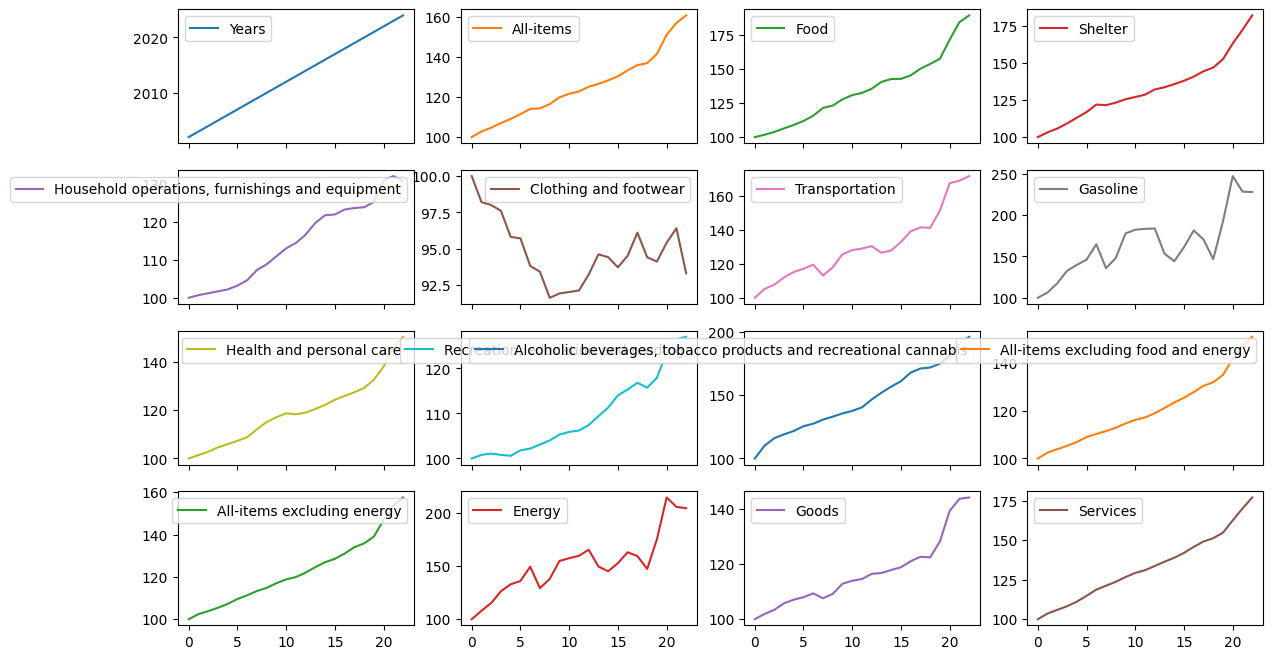

In [ ]:
df.plot(subplots = True, figsize = (14,8), layout = (4,4));

## Matplotlib

Ok... why does pandas use Matplotlib underneath the hood? Because Matplotlib is the foundation for nearly every Python visualization library you are likely to encounter. What is it? Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It is an incredibly rich, powerful, and extensive library that makes it possible to create basically any chart type you can think of. https://matplotlib.org/

<img src='https://drive.google.com/uc?id=1dol6Qy9sBxHNmgjHcKdfiNsrq9BvMRy3'>

You might encounter code that uses Pylab instead of Pyplot in its import statement. **Pyplot** provides the state-machine interface to the underlying plotting library in matplotlib. This means that figures and axes are implicitly and automatically created to achieve the desired plot. **Pylab** combines the pyplot functionality (for plotting) with the numpy functionality (for mathematics and for working with arrays) in a single namespace, making that namespace (or environment) even more MATLAB-like. For example, one can call the sin and cos functions just like you could in MATLAB, as well as having all the features of pyplot. The pyplot interface is generally preferred for non-interactive plotting. The pylab interface is convenient for interactive calculations and plotting, as it minimizes typing.

In [ ]:
# hence, why we usually write
import matplotlib.pyplot as plt

When you're working with Matplotlib, you need to learn its "grammar" and syntax - what the different parts of a graph (or "figure") are. The image below will be your most important reference. If you are familiar with ggplot2 (R), or D3 (JavaScript), or any other comparable visualization library, you will find that many of the different components are similar across different languages - even if they have different names. That said, there are things that are unique to Matplotlib, so the more you practice with it, the more it will make sense.

<img src='https://drive.google.com/uc?id=1zgbiY69zIC1RMgHv2PXgbnY0oUeXTh1Z'>

Let's replicate the basic chart we made in pandas (with a few more details).

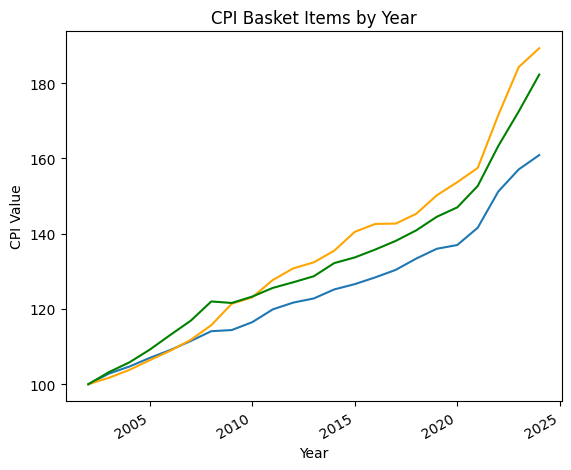

In [ ]:
## remember... we've already imported matplotlib and loaded our dataset into a pandas DataFrame in previous cells

# import matplotlib.pyplot as plt
# df = pd.read_csv("./Data/cpi.csv")

# X-axis is for time
year = df['Years']

# Y-axis is for our different basket item values
all_items = df['All-items']
food = df['Food']
shelter = df['Shelter']

# let's plot the time series of given dataset
plt.plot(year, all_items)
plt.plot(year, food, color='orange')
plt.plot(year, shelter, color='green')

# we should create a title for the graph
plt.title('CPI Basket Items by Year')

# to make it easier to read, rotate the x-axis tick labels at 30degree and towards right
plt.xticks(rotation=30, ha='right')

# add x and y labels
plt.xlabel('Year')
plt.ylabel('CPI Value')
plt.show()

There are lots of other things we could add (e.g. grid lines), but this is a pretty good example of a standard Matplotlib visualization. Be mindful that when you search something like "how do I make a bar/pie/line/etc. chart in Matplotlib," you are likely to see all kinds of code variations. Matplotlib syntax has changed a lot over the past decade, and there are a ton of Stack Overflow threads that repeat outdated code. That said, there's always more than one way to skin a cat.

So, while Matplotlib is powerful, and can often be bent and twisted to produce any kind of data graphic that other languages can handle, you will regularly find yourself needing to read the documentation and/or online threads for help. Because of this, a number of declarative, easy-to-understand Python libraries that make simple visualization less of a headache have emerged over the years. Let's look at a few of them.

## Seaborn

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level, declarative interface for drawing attractive and informative statistical graphics. Its comparatively simple syntax is easier to learn and understand than Matplotlib. It is designed to work hand-in-hand with pandas DataFrames. https://seaborn.pydata.org/

Text(0.5, 1.0, 'CPI 2002-2024')

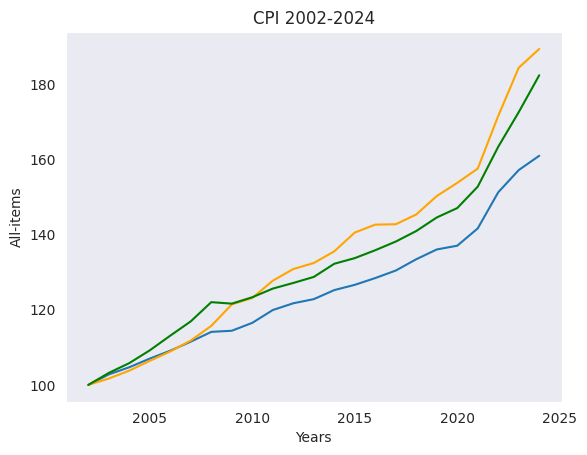

In [ ]:
import seaborn as sns

# seaborn has a number of elegant built-in themes
sns.set_style("dark")

# writing code for a line chart is nearly as easy as with the basic pandas .plot() method
sns.lineplot(x = 'Years', y = 'All-items', data = df)
sns.lineplot(x = 'Years', y = 'Food', data = df, color='orange')
sns.lineplot(x = 'Years', y = 'Shelter', data = df, color='green')
plt.title("CPI 2002-2024")

## Bokeh

Bokeh is a Python library for creating interactive visualizations for modern web browsers. It makes it easy to build beautiful graphics, ranging from simple plots to complex dashboards with streaming datasets. With Bokeh, you can create JavaScript-powered visualizations without writing any JavaScript yourself. It will output basic .html code that you can easily embed your visualization in a webpage. https://bokeh.org/

In [ ]:
from bokeh.models import ColumnDataSource, DatetimeTickFormatter
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

# Convert Years into datetime
df['YearDate'] = pd.to_datetime(df['Years'].astype(int), format='%Y')

# Bringing in data from pandas is relatively easy
source = ColumnDataSource(df)

# Bokeh's syntax, like Seaborn's, is easy to write and understand
p = figure(x_axis_type="datetime", width=800, height=350, title="CPI 2002-2024")

# Plot the three lines
p.line('YearDate', 'All-items', source=source, color = 'blue')
p.line('YearDate', 'Food', source=source, color='orange')
p.line('YearDate', 'Shelter', source=source, color='green')

# Format x-axis to show only years
p.xaxis.formatter = DatetimeTickFormatter(years="%Y")

# Rotate labels for readability
p.xaxis.major_label_orientation = 1.57 # ~90 degrees

# we can easily output our line chart as an .html file
#output_file("ts.html")
output_notebook()
show(p)

Try out the interactive tools (dragging; zooming). Notice anything wrong with the visualization, though? Look at the x-axis! You need to declare the type of date for "datetime" to interpret it as a year instead of in milliseconds.

## Altair

Altair is a declarative statistical visualization library for Python, based on Vega and Vega-Lite. Like Bokeh, it makes it easy to produce elegant, interactive graphics with minimal code. Altair's API is simple, friendly, and consistent, and built on top of the powerful Vega-Lite visualization grammar. If you are familiar with R and ggplot2, you might appreciate this "grammar-driven" approach to Python visualization. https://altair-viz.github.io/

In [ ]:
import altair as alt

# Vega-Altair's syntax and structure may be more comfortable for R and JavaScript users
alt.Chart(df).mark_line().encode(
    x='Years',
    y='All-items',
)

alt.Chart(...)

## Plotly

The final suite of libraries come from a data science platform called Plotly. Plotly's Python graphing libraries make it incredibly easy to produce publication-quality graphs for Python notebooks, interactive webpages, dashboards, and more. Notably, Plotly has a high degree of interoperability between different languages, so a Plotly Python visualization can easily be reproduced in R, JavaScript, and so on. https://plotly.com/python/

In [ ]:
# Let's start by using plotly graph_objects, which is closer to Matplotlib in its complexity
import plotly.graph_objects as go

# if we only want to draw one line chart for our All-items basket
#fig = go.Figure([go.Scatter(x=df['Years'], y=df['All-items'])])

# if we want to do more than one line, this line will create a graph objects "figure"
fig = go.Figure()

# these lines will add "scatterplot lines" to our figure
fig.add_trace(go.Scatter(x=df['Years'], y=df['Food'], name="Food", line=dict(color="orange")))
fig.add_trace(go.Scatter(x=df['Years'], y=df['Shelter'], name="Shelter", line=dict(color="green")))

# and this code will allow us to update the figure's layout/aesthetics
fig.update_layout(
    autosize=False,
    width=800,
    height=400,
    margin=dict(
        l=50,
        r=50,
        b=100,
        t=100,
        pad=4
    ),
    paper_bgcolor="AliceBlue",
)

# this line will display it in our notebook
fig.show()

Make sure to hover over the graphic to activate some of the interactive features including panning, zooming, and brushing for context.

Because Graph Objects can be relatively complex, Plotly Express makes it easy to do the same thing with much less code. Think of it like the Seaborn to Graph Objects' Matplotlib.

In [ ]:
# using plotly express
import plotly.express as px

# create a figure with a line chart in it
# the chart will get its data from df, and will use year and food for its x and y axes
fig = px.line(df, x='Years', y="Food", width=800, height=400)
fig.show()

# note that the same interactive features as in Plotly GO can be activated by hovering over an Express graph

The real power of Plotly, however, comes with its Dash library. Plotly's marketing for Dash describes it like this: Dash apps give a point-&-click interface to models written in Python, vastly expanding the notion of what's possible in a traditional "dashboard." With Dash apps, data scientists and engineers put complex Python analytics in the hands of business decision-makers and operators.

In reality, Dash is probably the most accessible, developer-friendly, and scalable Python-based tool for building data applications that require multiple visualizations (e.g. dashboards). The code in the cell below will create a Dash app with our CPI line chart. Adding additional charts is as simple as adding a few lines of Express or GO code. Feel free to uncomment it if your notebook application supports Dash apps.

In [ ]:
#from dash import Dash, dcc, html, Input, Output

#app = Dash(__name__)

#app.layout = html.Div([
#    html.H4('CPI 2000-2024'),
#    dcc.Graph(id="graph"),
#    dcc.Checklist(
#        id="checklist",
#        inline=True
#    ),
#])

#@app.callback(
#    Output("graph", "figure"),
#    Input("checklist", "value"))
#def update_line_chart(cpi):
#    fig = px.line(df, x='Years', y="All-items", width=800, height=400)
#    return fig

#app.run_server(debug=False)

## Things We Can Do With Time Series Visualization

So far, we've only touched the surface of what we can do with these Python visualization libraries. These basic line charts will help us understand trends, but not much more. What additional things might we do to make more sense of the CPI data? We could:

- Add trend lines using linear regression methods
- Split the lines into interactive small multiples (aka facet plots)
- Use Plotly as the back-end for pandas with this line: pd.options.plotting.backend = "plotly"
- Annotate the visuals
- Add additional interactive features
- Familiarize ourselves with appropriate x-y ratios for time series charts https://chezvoila.com/blog/yaxis/

## Additional Resources

While Matplotlib and its various front-end libraries are powerful, there are a host of other resources you should familiarize yourself with if you want to do advanced visualization in Python.

- https://www.python-graph-gallery.com/ The Python Graph Gallery is a comprehensive go-to source for explanations, examples, and Python code when you are looking to create new visualizations.
- http://ft-interactive.github.io/visual-vocabulary/ The graphics team at the Financial Post have an excellent tool that will help you choose the most appropriate chart type for your data.
- https://www.data-to-viz.com/ Data to Viz is a great mix of the previous projects.
- https://datavizcatalogue.com/ The Data Viz Catalogue is similar to Data to Viz in that it provides examples, explanations for how a chart works, and links to template code.
- https://www.storytellingwithdata.com/chart-guide The folks at Storytelling with Data have a great overview site that will help you understand how different chart types work.
- https://blog.datawrapper.de/colorguide/ Lisa Charlotte Muth at Datawrapper wrote an excellent overview of colour choices for data visualization. It's worth reading this to understand why certain palettes are better than others, and how colour can produce misleading graphics.
- https://projects.susielu.com/viz-palette Viz Palette is an excellent tool by some important folks in the infovis world. It will make it easy for you to generate colour palettes and themes that make your work stand out.
- https://docs.enthought.com/mayavi/mayavi/ MayaVi is a powerful tool for 3D and Scientific Visualization in Python. While it can be hard to use, and isn't particularly well-documented, it is indispensable if you want to create 3D graphics.
- https://medium.com/nightingale/how-to-create-eye-catching-maps-with-python-and-kepler-gl-e7e897eff8ac Uber's Kepler.gl tool is great for geospatial analysis and has a Python interface that makes it ideal for visualizing large geospatial datasets. It has been replaced, more or less, by Foursquare Studio. https://studio.foursquare.com/

## Additional Resources for Learning Python

- https://www.datacamp.com/courses/intro-to-python-for-data-science
- https://www.youtube.com/watch?v=LHBE6Q9XlzI
- https://developers.google.com/edu/python/
- https://docs.python-guide.org/
- https://www.linkedin.com/learning/topics/python


## Today's Key Takeaways

If you want to become comfortable analyzing and visualizing data in Python, you'll need to be active. Try different datasets and challenges, engage with different libraries, share your graphics with peers (and revise based on feedback), and, most important, enjoy yourself! Visualization is arguably the most fun part of data analytics!! With that in mind, there are a few important takeaways from today.

- To truly understand visualization in Python, you should learn Matplotlib! It will be daunting at first, but the more you understand how to prepare visualizations with Matplotlib, the easier it will be to make sense of your data. Stack Overflow and YouTube will be the best sources of information for learning and troubleshooting.
- To really speed up your workflow, you should learn one of the front-end libraries and use it consistently. If you're new to Python programming, Seaborn or Plotly Express are probably your best options, as they make simple graphics easy to produce in just a few lines of code. In this program - and in your careers - you should probably stick with basic visualizations. There are countless ways to visualize data - flowcharts, bar graphs, infographics, maps, pie charts, scatterplots, histograms, and so on. Choose visuals that will make it easy for your audience to understand and engage with the data. The front-end libraries outlined in this notebook make it easy to do so.
- If you anticipate working with big datasets or developing interactive graphics and/or dashboards, learn Plotly (+Dash) or Bokeh (+Holoviews https://holoviews.org/).

## Challenge

If you're up for a challenge now that you've learned some basics, take a crack at the following one.

*Use one of the visualization libraries described in this notebook to show which CPI category has experienced the most growth over the past 5 years. Taking into account the fact that the data ends in 2022, come up with an explanation for its growth. Render a publishable graphic (with titles, legend, etc.) and arrange it in a document with accompanying explanatory text.*

Here are a few other questions you might consider while examining this data: Is the CPI growing for all basket categories? Which category has the lowest rate of growth? The wildest and most unpredictable rate of growth? Are Food and Shelter (the two categories we considered today) growing at the same pace?

## Some Fun CPI Visualization Examples

When you're done, here are some fun recent CPI visualization examples from various news sites. Most will have been developed using JavaScript libraries like D3 for the browser-based interactive components, but there's a good chance that the underlying data science processes will have been Python-driven.

- https://www.politico.com/interactives/2022/food-prices-rising-inflation-2022
- https://www.washingtonpost.com/business/interactive/2022/inflation-quiz/
- https://www.theguardian.com/business/ng-interactive/2022/jun/21/cost-of-living-crisis-uk-households-charts-inflation
- https://ici.radio-canada.ca/info/2022/panier-epicerie/hausse-prix-aliments-inflation-pouvoir-achat
- https://www.nytimes.com/interactive/2022/05/08/business/economy/inflation-calculator.html
